### 1. Imports

In [1]:
import os
import requests
from typing import TypedDict

from langchain.tools import tool
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, START, END
from pinecone import Pinecone

### 2. Configuration

##### Open AI Key

In [6]:
with open(r"E:\Lenovo Ideapad 330\company-material\digital-workforce-transformation\ai-upskill-8\key-vault\openai\api.key") as f:
    openai_api_key = f.read().strip()
os.environ["OPENAI_API_KEY"] = openai_api_key

##### URL for Flowise RAG Capstone Project

In [3]:
RAG_URL = r"https://cloud.flowiseai.com/api/v1/prediction/c7f91a50-e934-4842-80a8-539738a31cd9"

##### NVD API Key

In [16]:
with open(r"E:\Lenovo Ideapad 330\company-material\digital-workforce-transformation\ai-upskill-9\key-vault\nvd-database\api.key") as f:
    nvd_api_key = f.read().strip()
NVD_API_KEY = nvd_api_key

##### LLM Configuration

In [5]:
MODEL = "gpt-4.1-mini"

In [7]:
llm = ChatOpenAI(model=MODEL, temperature=0)

### 3. Tool Layer

##### CIS Tool

In [9]:
def query(payload):
    response = requests.post(RAG_URL, json=payload)
    return response.json()

output = query({
    "question": "Give windows password requrirements",
})

print(output["text"])

Here are the Windows password requirements based on the CIS guidelines:

1. **Password Complexity**:
   - Passwords must meet complexity requirements. 
   - This means passwords should not contain the user’s account name or parts of the user’s full name that exceed two consecutive characters.
   - The requirement can be enforced by ensuring the policy "Password must meet complexity requirements" is set to **Enabled**.

2. **Minimum Password Length**:
   - The minimum password length should be set to **14 or more characters**. 
   - This policy setting determines the least number of characters that make up a password for a user account.

3. **Relax Minimum Password Length Limits**:
   - Ensure that the "Relax minimum password length limits" policy is set to **Enabled**.

4. **Store Passwords using Reversible Encryption**:
   - The setting for "Store passwords using reversible encryption" must be set to **Disabled** to enhance security.

5. **Account Lockout Policy**:
   - For increased 

In [15]:
@tool
def ask_cis(question: str) -> str:
    """Retrieve information from the CIS benchmark knowledge base for guidance"""
    print("[TOOL]CIS Tool Activated")
    output = query({
        "question": question
    })
    return output["text"]

#print(ask_cis("Give me Windows security settings"))

##### NVD Tool

In [36]:
@tool
def lookup_cve(keyword:str)->str:
    """Query the NVD API for CVEs matching a keyword."""
    print("[TOOL]CVE Tool Activated")
    url = "https://services.nvd.nist.gov/rest/json/cves/2.0"
    headers = {"apiKey": NVD_API_KEY} if NVD_API_KEY else {}
    params = {"keywordSearch": keyword, "resultsPerPage": 3}
    try:
        r = requests.get(url, params=params, headers=headers, timeout=20)
        r.raise_for_status()
        data = r.json()
        vulns = data.get("vulnerabilities", [])
        if not vulns:
            return "No CVEs found."
        lines = []
        for v in vulns:
            c = v["cve"]
            lines.append(f"{c['id']}: {c['descriptions'][0]['value'][:180]}")
        return "\n".join(lines)
    except Exception as e:
        return f"CVE lookup failed: {e}"

### 3. Agents Layer

In [18]:
planner = create_agent(
    model=llm,
    tools=[],
    system_prompt="You are a planner. Decide weather RAG and CVE lookup is required"
)

In [37]:
retrieval_agent = create_agent(
    model=llm,
    tools=[ask_cis],
    system_prompt="Use the RAG tool to retrieve CIS benchmark guidance. Use the provided tools mandatorily."
)

Use to test independetly: retrieval_agent.invoke()

In [38]:
threat_agent = create_agent(
    model=llm,
    tools=[lookup_cve],
    system_prompt="Use CVE lookup tool when threat intelligence is needed. Use the provided tools mandatorily."
)

Use to test independetly: threat_agent.invoke()

In [39]:
validator_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt="Validate the evidence and produce a concise final answer"
)

### 4. LangGraph State

In [40]:
class CyberState(TypedDict):
    query: str
    plan: str
    rag: str
    cves: str
    final: {}

### 5. Nodes

In [41]:
def planner_node(state: CyberState):
    r = planner.invoke({
        "messages":[
            {"role":"user", "content":state["query"]}
        ]
    })
    return {"plan": str(r)}

In [42]:
def rag_node(state: CyberState):
    r = retrieval_agent.invoke({
        "messages":[
            {"role":"user", "content":state["query"]}
        ]
    })
    return {"rag": str(r)}

In [43]:
def cve_node(state: CyberState):
    r = threat_agent.invoke({
        "messages":[
            {"role":"user", "content":state["query"]}
        ]
    })
    return {"cves": str(r)}

In [44]:
def validator_node(state: CyberState):

    prompt = f"""
User Query:
{state["query"]}

Plan:
{state.get("plan", "")}

RAG:
{state.get("rag", "")}

CVEs:
{state.get("cves", "")}

SCORE:
validation score

Produce the final validated response.
Also, give a score from 0 to 10
"""
    r = validator_agent.invoke({
        "messages":[
            {"role":"user", "content":prompt}
        ]
    })
    return {"final": r}

### 6. Build the Workflow

In [45]:
graph = StateGraph(CyberState)

graph.add_node("planner", planner_node)
graph.add_node("rag", rag_node)
graph.add_node("cve", cve_node)
graph.add_node("validator", validator_node)

graph.add_edge(START, "planner")
graph.add_edge("planner", "rag")
graph.add_edge("rag", "cve")
graph.add_edge("cve", "validator")
graph.add_edge("validator", END)


In [46]:
app = graph.compile()

### 7. Execute

In [47]:
result = app.invoke({
    "query": "How can I harden Windows SMB services against ransomware?"
})

In [48]:
print(result["final"]["messages"][-1].content)

To harden Windows SMB services against ransomware, follow these validated best practices:

1. **Disable SMBv1**: SMBv1 is outdated and vulnerable. Disable both the SMBv1 client driver and server components to prevent exploitation.

2. **Mandate Minimum SMB Version 3.1.1**: Enforce use of SMB version 3.1.1 or higher to leverage improved security features.

3. **Enable SMB Security Features**:
   - Enable Certificate Padding to enhance cryptographic protections.
   - Enable SMB signing to ensure integrity and authenticity of SMB communications.

4. **Configure Auditing**:
   - Enable auditing for insecure guest logons.
   - Audit servers that do not support encryption.
   - Collect detailed audit logs to monitor and respond to suspicious SMB activity.

5. **Set Authentication Rate Limiter**: Configure authentication rate limiter delay (e.g., 2000 milliseconds or more) to mitigate brute-force attacks.

6. **Restrict SMB Access**:
   - Limit SMB access to only necessary users and systems.


In [49]:
result

{'query': 'How can I harden Windows SMB services against ransomware?',
 'plan': "{'messages': [HumanMessage(content='How can I harden Windows SMB services against ransomware?', additional_kwargs={}, response_metadata={}, id='c065470c-13d7-4b89-8bde-1babcdc13547'), AIMessage(content='RAG (Retrieval-Augmented Generation) and CVE (Common Vulnerabilities and Exposures) lookup would be useful here to provide the most up-to-date and specific security measures and known vulnerabilities related to Windows SMB services.\\n\\nI will proceed with RAG and CVE lookup to gather detailed and current information on hardening Windows SMB services against ransomware.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 37, 'total_tokens': 108, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 

In [50]:
result = app.invoke({
    "query": "Recommend CIS settings for Windows RDP and include recent vulnerabilities that administrators should patch."
})

[TOOL]CVE Tool Activated
[TOOL]CVE Tool Activated


In [51]:
print(result["final"]["messages"][-1].content)

Recommended CIS Settings for Windows Remote Desktop Protocol (RDP):

1. **Enable Network Level Authentication (NLA):** Require user authentication before establishing a full RDP session to prevent unauthorized access.

2. **Enforce Strong Encryption:**
   - Use 128-bit encryption or higher for all RDP communications.
   - Set encryption level to "Enabled: SSL" which enforces Transport Layer Security (TLS), preferred over native RDP encryption.

3. **Group Policy Configuration:**
   - Enable secure RPC communication:
     `Computer Configuration\Policies\Administrative Templates\Windows Components\Remote Desktop Services\Remote Desktop Session Host\Security\Require secure RPC communication`

4. **Session Time Limits:**
   - Limit active but idle sessions to 15 minutes or less.
   - Limit disconnected sessions to 1 minute.
   - Configure these via Group Policy under:
     `Computer Configuration\Policies\Administrative Templates\Windows Components\Remote Desktop Services\Remote Desktop S

In [52]:
result

{'query': 'Recommend CIS settings for Windows RDP and include recent vulnerabilities that administrators should patch.',
 'plan': "{'messages': [HumanMessage(content='Recommend CIS settings for Windows RDP and include recent vulnerabilities that administrators should patch.', additional_kwargs={}, response_metadata={}, id='29eed6b3-d7d0-42f9-b707-fd1494a6ff82'), AIMessage(content='For securing Windows Remote Desktop Protocol (RDP), it is important to follow CIS (Center for Internet Security) benchmarks and also be aware of recent vulnerabilities to patch.\\n\\n1. CIS Settings for Windows RDP:\\n- Enable Network Level Authentication (NLA) to require user authentication before establishing a session.\\n- Limit RDP access to specific IP addresses or VPNs using firewall rules.\\n- Configure RDP to use strong encryption and security layers.\\n- Set account lockout policies to prevent brute force attacks.\\n- Disable RDP if not needed.\\n- Enable logging and monitoring of RDP connections.\\n

### 8. Visualize

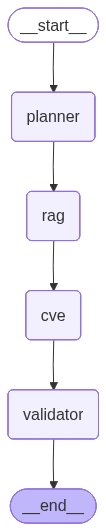

In [53]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Visualization unavailable:", e)